#  Financial Fraud Detection - Data Science Project
**Phase 1**: Exploration & Preprocessing  

---

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import joblib

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

### 1. Data Understanding
We load the dataset and perform a sanity check on missing values and data types.

In [35]:
# Updated Path: Looking in the root directory from the 'notebooks' folder
try:
    df = pd.read_csv('creditcard.csv')
    print(" Dataset Loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    try:
        df = pd.read_csv('creditcard.csv')
        print(" Dataset Loaded successfully (local)!")
    except FileNotFoundError:
        print(" File not found. Make sure 'creditcard.csv' is in the root project folder.")

if 'df' in locals():
    print(f"Missing Values: {df.isnull().sum().max()}")
    display(df.head())

 Dataset Loaded successfully!
Shape: 284807 rows, 31 columns
Missing Values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**📝 Insights:**
* **Zero Missing Values:** The dataset is clean, so we don't need imputation.
* **PCA Features:** Columns V1-V28 are anonymized PCA components. Only `Time`, `Amount`, and `Class` are in their original format.
* **Imbalance Warning:** We need to check the ratio of Class 1 (Fraud) to Class 0 (Legit) immediately.

Class Ratios (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


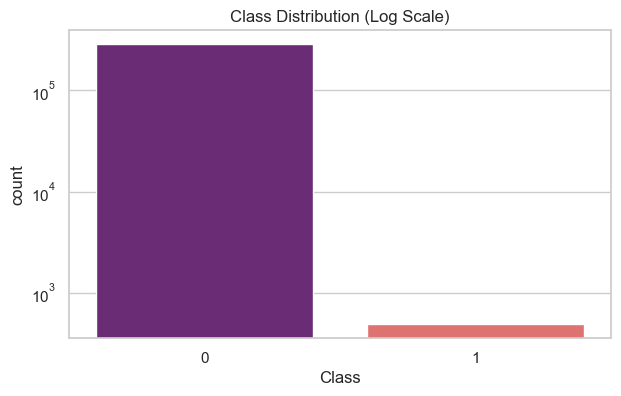

In [36]:
if 'df' in locals():
    print("Class Ratios (%):")
    print(df['Class'].value_counts(normalize=True) * 100)
    
    plt.figure(figsize=(7, 4))
    sns.countplot(x='Class', data=df, palette='magma')
    plt.title('Class Distribution (Log Scale)')
    plt.yscale('log')
    plt.show()

**📝 Insights:**
* **Extreme Skew:** Only **0.17%** is fraud. A simple model predicting 'Legit' every time would get 99.8% accuracy but catch 0% fraud. 
* **Strategy:** We must use metrics like **AUPRC** (Area Under Precision-Recall Curve) instead of accuracy.

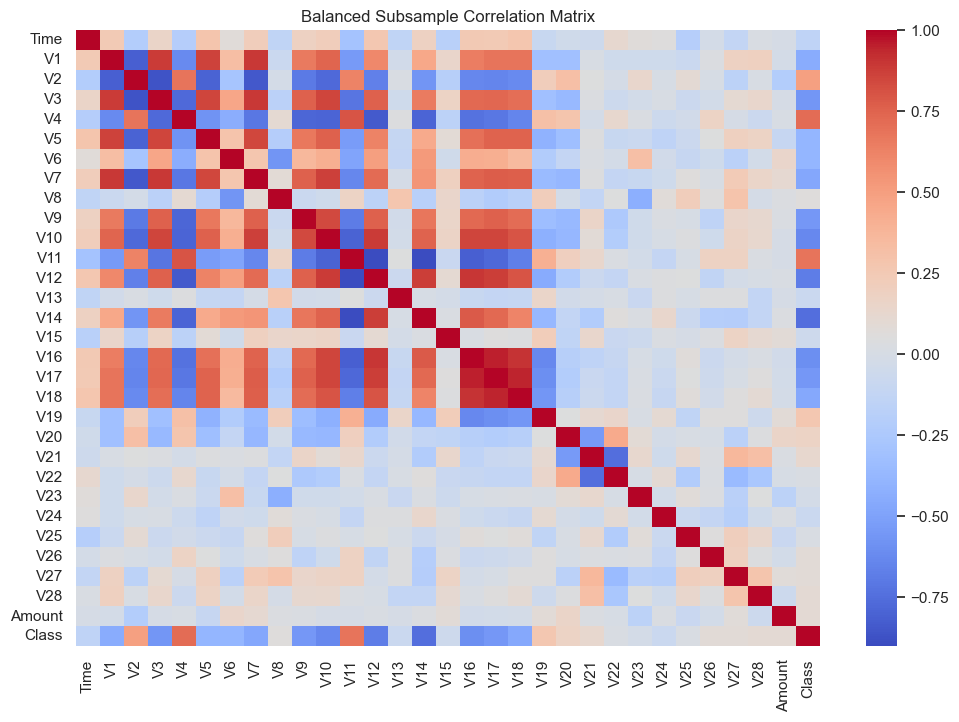

Strongest Negative Correlations:
 V14   -0.749228
V12   -0.682039
V10   -0.628327
Name: Class, dtype: float64


In [37]:
if 'df' in locals():
    # Subsampling for clearer correlation analysis
    # Without subsampling, the imbalance hides the true correlations
    fraud_sub = df[df['Class'] == 1]
    legit_sub = df[df['Class'] == 0].sample(n=len(fraud_sub), random_state=42)
    balanced_sub = pd.concat([fraud_sub, legit_sub]).sample(frac=1)

    plt.figure(figsize=(12, 8))
    corr = balanced_sub.corr()
    sns.heatmap(corr, cmap='coolwarm', annot=False)
    plt.title('Balanced Subsample Correlation Matrix')
    plt.show()
    
    print("Strongest Negative Correlations:\n", corr['Class'].sort_values().head(3))

**📝 Insights:**
* **V14, V12, V10:** These show strong negative correlation with Fraud. When these values drop, the probability of Fraud spikes. These are our best indicators.
* **V4, V11:** These show positive correlation. Higher values indicate a higher fraud risk.

In [38]:
if 'df' in locals():
    # Scaling Time and Amount using RobustScaler (less sensitive to outliers)
    if 'Amount' in df.columns:
        rob_scaler = RobustScaler()
        df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
        df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
        df.drop(['Time','Amount'], axis=1, inplace=True)

  
        joblib.dump(rob_scaler, 'robust_scaler.pkl')
        print("RobustScaler fitted and saved successfully!")
        
    display(df.head(2))

RobustScaler fitted and saved successfully!


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983


**✅ Phase 1 Complete.**
The data is processed, insights generated, and the dataframe is ready for Phase 2: Classification Modeling.

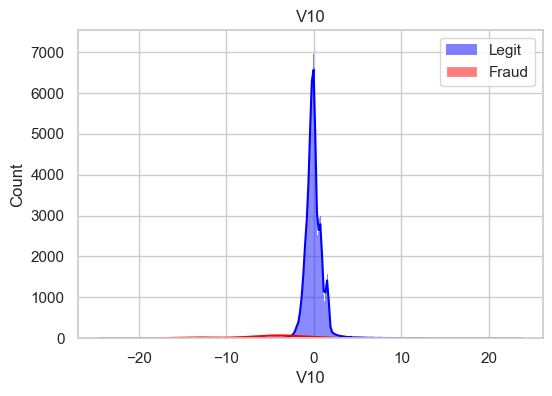

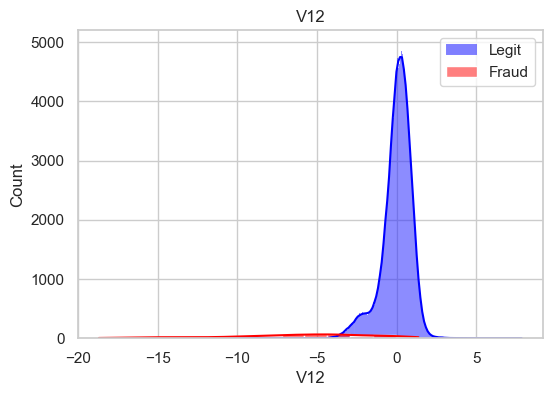

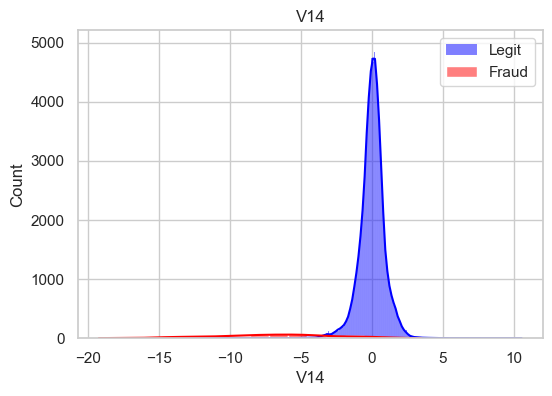

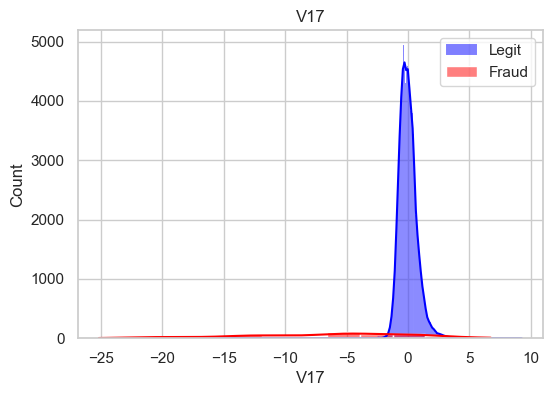

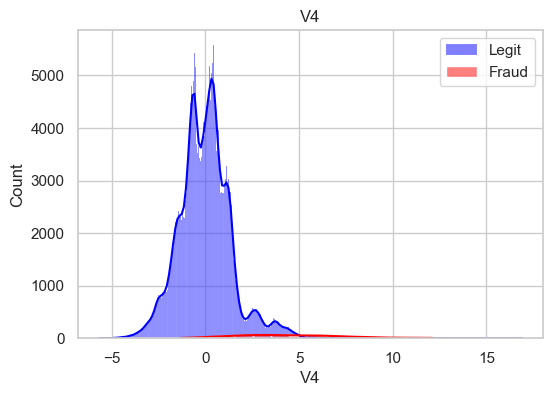

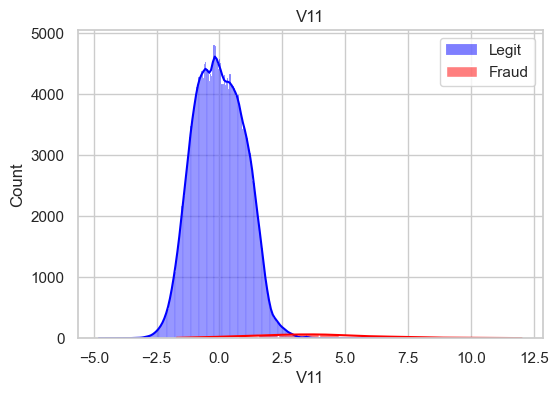

In [39]:
features = ['V10', 'V12', 'V14', 'V17','V4','V11']

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[df['Class']==0][col], color='blue', label='Legit', kde=True)
    sns.histplot(df[df['Class']==1][col], color='red', label='Fraud', kde=True)
    plt.title(col)
    plt.legend()
    plt.show()

V14 and V17 clearly separate fraud and normal transactions.
Fraud values are more negative, making these features highly useful.
V4 and V11 show positive correlation, where fraud values are higher than normal.
So, higher values of these features indicate higher chance of fraud

RandomForestClassifier trained successfully.
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        87
           1       0.97      0.90      0.93       110

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197

Confusion Matrix:
[[84  3]
 [11 99]]
RMSE: 0.2665820508731144
AUC-ROC Score: 0.9863


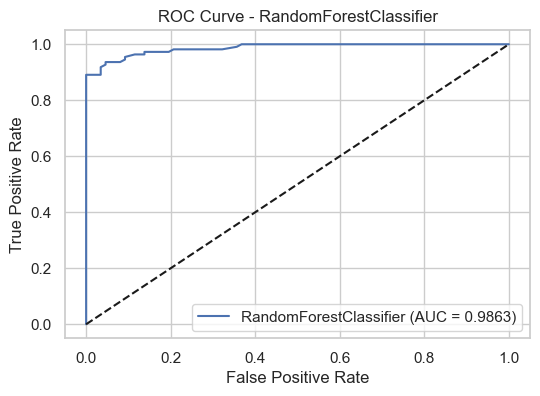

Test on mixed Class 0 and Class 1 sample:
Mixed Sample Class Distribution:
Class
1    100
0    100
Name: count, dtype: int64
Mixed Sample Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.99      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

Mixed Sample Confusion Matrix:
[[99  1]
 [ 2 98]]
LogisticRegression trained successfully.
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        87
           1       0.96      0.92      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197

Confusion Matrix:
[[ 83   4]
 [  9 101]]
RMSE: 0.25688489195695424
AUC-ROC Score: 0.98

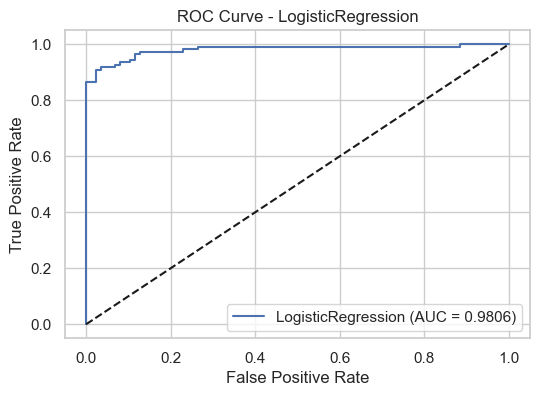

Test on mixed Class 0 and Class 1 sample:
Mixed Sample Class Distribution:
Class
1    100
0    100
Name: count, dtype: int64
Mixed Sample Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       100
           1       0.98      0.94      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Mixed Sample Confusion Matrix:
[[98  2]
 [ 6 94]]
XGBClassifier trained successfully.
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        87
           1       0.96      0.92      0.94       110

    accuracy                           0.93       197
   macro avg       0.93      0.94      0.93       197
weighted avg       0.94      0.93      0.93       197

Confusion Matrix:
[[ 83   4]
 [  9 101]]
RMSE: 0.25688489195695424
AUC-ROC Score: 0.9851


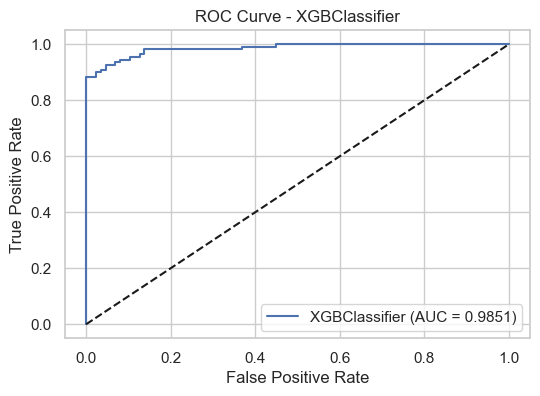

Test on mixed Class 0 and Class 1 sample:
Mixed Sample Class Distribution:
Class
1    100
0    100
Name: count, dtype: int64
Mixed Sample Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.99      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

Mixed Sample Confusion Matrix:
[[99  1]
 [ 2 98]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split


# Build a balanced training subset from the CURRENT df so train/test feature schema is consistent.
fraud_sub_model = df[df['Class'] == 1]
legit_sub_model = df[df['Class'] == 0].sample(n=len(fraud_sub_model), random_state=42)
balanced_sub_model = pd.concat([fraud_sub_model, legit_sub_model]).sample(frac=1, random_state=42)

X = balanced_sub_model.drop('Class', axis=1)
y = balanced_sub_model['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = [
    RandomForestClassifier(n_estimators=100, random_state=42),
    LogisticRegression(max_iter=1000),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss')
]


for model in models:
    model.fit(X_train, y_train)
    print(f"{model.__class__.__name__} trained successfully.")

    y_pred = model.predict(X_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("RMSE:", np.sqrt(np.mean((y_test - y_pred) ** 2)))

    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"AUC-ROC Score: {auc_score:.4f}")

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model.__class__.__name__} (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model.__class__.__name__}')
    plt.legend(loc='lower right')
    plt.show()

    print("Test on mixed Class 0 and Class 1 sample:")
    n_each = 100

    fraud_mixed = df[df['Class'] == 1].sample(n=min(n_each, (df['Class'] == 1).sum()), random_state=42)
    legit_mixed = df[df['Class'] == 0].sample(n=min(n_each, (df['Class'] == 0).sum()), random_state=42)

    mixed_test = pd.concat([fraud_mixed, legit_mixed]).sample(frac=1, random_state=42).reset_index(drop=True)

    # Force identical feature set/order as training.
    X_mixed = mixed_test[X.columns]
    y_mixed = mixed_test['Class']

    y_mixed_pred = model.predict(X_mixed)

    print("Mixed Sample Class Distribution:")
    print(y_mixed.value_counts())
    print("Mixed Sample Report:")
    print(classification_report(y_mixed, y_mixed_pred))
    print("Mixed Sample Confusion Matrix:")
    print(confusion_matrix(y_mixed, y_mixed_pred))

Random Forest performed the best among all models.
It gave zero false positives and fewer missed fraud cases.
It achieved 100% precision, making it the most reliable model.